# Projet Data Science - Rétention Client
## 01. Analyse Exploratoire des Données (EDA) et Préparation

Dans ce notebook, nous allons explorer le jeu de données pour mieux comprendre les comportements des clients et préparer les données pour la modélisation de la résiliation (Churn).

L'objectif de cette étape est de :
- Comprendre la distribution de nos données.
- Gérer les valeurs manquantes ou aberrantes.
- Analyser les corrélations entre les caractéristiques des clients et le risque de résiliation.
- Préparer un jeu de données propre pour l'entraînement des modèles.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configuration de l'affichage
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
print("Librairies chargées avec succès.")

Librairies chargées avec succès.


### 1. Chargement des données
Nous commençons par charger le dataset depuis le répertoire `data`.

In [2]:
data_path = '../data/customer_churn_business_dataset.csv'
df = pd.read_csv(data_path)
print(f"Dataset chargé : {df.shape[0]} lignes, {df.shape[1]} colonnes")
display(df.head())

Dataset chargé : 10000 lignes, 32 colonnes


,customer_id,gender,age,country,city,customer_segment,tenure_months,signup_channel,contract_type,monthly_logins,...,avg_resolution_time,complaint_type,csat_score,escalations,email_open_rate,marketing_click_rate,nps_score,survey_response,referral_count,churn
0,CUST_00001,Male,68,Bangladesh,London,SME,22,Web,Monthly,26,...,13.354360,Service,4.0,0,0.71,0.40,27,Satisfied,1,0
1,CUST_00002,Female,57,Canada,Sydney,Individual,9,Mobile,Monthly,7,...,25.140088,Billing,2.0,0,0.78,0.33,-19,Neutral,2,1
2,CUST_00003,Male,24,Germany,New York,SME,58,Web,Yearly,19,...,27.572928,Service,3.0,0,0.35,0.49,80,Neutral,1,0
3,CUST_00004,Male,49,Australia,Dhaka,Individual,19,Mobile,Yearly,34,...,26.420822,Technical,5.0,1,0.83,0.15,100,Neutral,0,0
4,CUST_00005,Male,65,Bangladesh,Delhi,Individual,52,Web,Monthly,20,...,26.674579,Technical,4.0,0,0.65,0.44,21,Unsatisfied,1,0


### 2. Vue d'ensemble du jeu de données
Vérifions les types de variables et la présence de valeurs manquantes.

In [3]:
print(f"Dimensions du dataset : {df.shape[0]} lignes, {df.shape[1]} colonnes\n")
df.info()

Dimensions du dataset : 10000 lignes, 32 colonnes



<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 32 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             10000 non-null  str    
 1   gender                  10000 non-null  str    
 2   age                     10000 non-null  int64  
 3   country                 10000 non-null  str    
 4   city                    10000 non-null  str    
 5   customer_segment        10000 non-null  str    
 6   tenure_months           10000 non-null  int64  
 7   signup_channel          10000 non-null  str    
 8   contract_type           10000 non-null  str    
 9   monthly_logins          10000 non-null  int64  
 10  weekly_active_days      10000 non-null  int64  
 11  avg_session_time        10000 non-null  float64
 12  features_used           10000 non-null  int64  
 13  usage_growth_rate       10000 non-null  float64
 14  last_login_days_ago     10000 non-null  int64  
 1

In [4]:
print("Statistiques descriptives :")
display(df.describe())

Statistiques descriptives :


,age,tenure_months,monthly_logins,weekly_active_days,avg_session_time,features_used,usage_growth_rate,last_login_days_ago,monthly_fee,total_revenue,payment_failures,support_tickets,avg_resolution_time,csat_score,escalations,email_open_rate,marketing_click_rate,nps_score,referral_count,churn
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.0000,10000.000000
mean,45.906100,30.155700,19.672000,3.479400,15.187890,4.990800,0.019423,9.505200,34.930000,1057.018000,0.501000,1.206600,23.953210,3.486700,0.294100,0.499610,0.253575,19.110500,0.9922,0.102100
std,16.420416,17.099517,9.838003,2.302283,6.830774,2.211607,0.149567,9.799417,23.785115,1020.148233,0.711934,1.104554,9.956999,0.978631,0.543171,0.231601,0.140532,38.936619,0.9939,0.302795
min,18.000000,1.000000,0.000000,0.000000,1.000000,1.000000,-0.580000,0.000000,10.000000,10.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.100000,0.010000,-100.000000,0.0000,0.000000
25%,32.000000,16.000000,13.000000,1.000000,10.391645,3.000000,-0.080000,2.000000,20.000000,340.000000,0.000000,0.000000,17.082041,3.000000,0.000000,0.300000,0.130000,-7.000000,0.0000,0.000000
50%,46.000000,30.000000,20.000000,3.000000,15.161659,5.000000,0.020000,6.000000,30.000000,720.000000,0.000000,1.000000,23.950444,4.000000,0.000000,0.500000,0.250000,19.000000,1.0000,0.000000
75%,60.000000,45.000000,26.000000,5.000000,19.882034,6.000000,0.120000,13.000000,50.000000,1440.000000,1.000000,2.000000,30.758480,4.000000,1.000000,0.700000,0.380000,46.000000,2.0000,0.000000
max,74.000000,59.000000,54.000000,7.000000,41.996411,15.000000,0.540000,80.000000,100.000000,5900.000000,5.000000,7.000000,61.821878,5.000000,4.000000,0.900000,0.500000,100.000000,7.0000,1.000000


In [5]:
# Vérification des valeurs manquantes
missing_values = df.isnull().sum()
missing_pct = (missing_values / len(df)) * 100
missing_df = pd.DataFrame({'Valeurs manquantes': missing_values, 'Pourcentage (%)': missing_pct})
missing_with_data = missing_df[missing_df['Valeurs manquantes'] > 0]

if len(missing_with_data) == 0:
    print(" Aucune valeur manquante détectée dans le dataset.")
else:
    print(" Colonnes avec valeurs manquantes :")
    display(missing_with_data)

 Colonnes avec valeurs manquantes :


,Valeurs manquantes,Pourcentage (%)
complaint_type,2045,20.45


**Interprétation :**
Le jeu de données contient plus de 10 000 clients et environ 32 variables. Nous avons un mélange de variables catégorielles (comme le genre, le pays, le type de contrat) et numériques (comme l'âge, les revenus, l'engagement). Le dataset est propre, sans valeurs manquantes, ce qui nous permet de passer directement à l'exploration sans étape d'imputation.

### 3. Analyse de la variable cible (Churn)
L'objectif est de prédire le 'churn'. Observons le déséquilibre des classes.

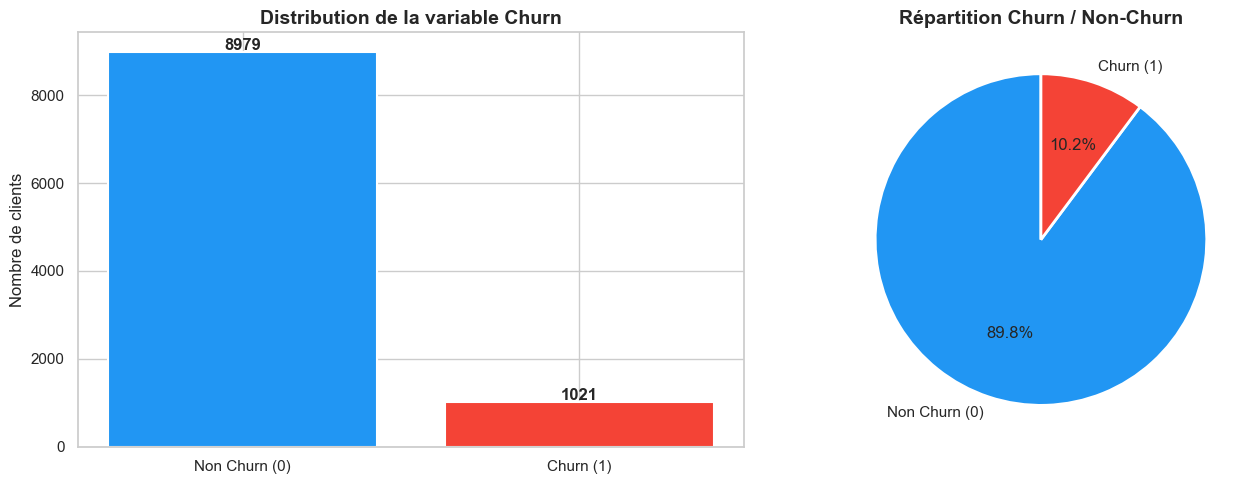


Taux de résiliation (Churn rate) : 10.21%
Clients fidèles : 8979 (89.79%)
Clients ayant résilié : 1021 (10.21%)


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution du churn
churn_counts = df['churn'].value_counts()
churn_labels = ['Non Churn (0)', 'Churn (1)']
colors = ['#2196F3', '#F44336']

axes[0].bar(churn_labels, churn_counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Distribution de la variable Churn', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Nombre de clients')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold', fontsize=12)

# Pie chart
axes[1].pie(churn_counts.values, labels=churn_labels, autopct='%1.1f%%',
            colors=colors, startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Répartition Churn / Non-Churn', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

churn_rate = df['churn'].mean() * 100
print(f"\nTaux de résiliation (Churn rate) : {churn_rate:.2f}%")
print(f"Clients fidèles : {churn_counts[0]} ({100-churn_rate:.2f}%)")
print(f"Clients ayant résilié : {churn_counts[1]} ({churn_rate:.2f}%)")

**Interprétation :**
Le jeu de données présente un déséquilibre des classes. Il y a plus de clients fidèles que de clients qui ont résilié. Si ce déséquilibre est notable, nos modèles pourraient être biaisés vers la prédiction de la classe majoritaire. Nous devrons utiliser des métriques comme le F1-score et le ROC AUC plutôt que la simple accuracy. Nous utiliserons également un split stratifié pour conserver cette proportion dans nos jeux d'entraînement et de test.

### 4. Analyses Bivariées (Caractéristiques vs Churn)
Explorons l'impact de certaines variables clés sur le risque de résiliation.

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_45396\858829009.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='churn', y='csat_score', data=df, palette='Set2', ax=axes[1])


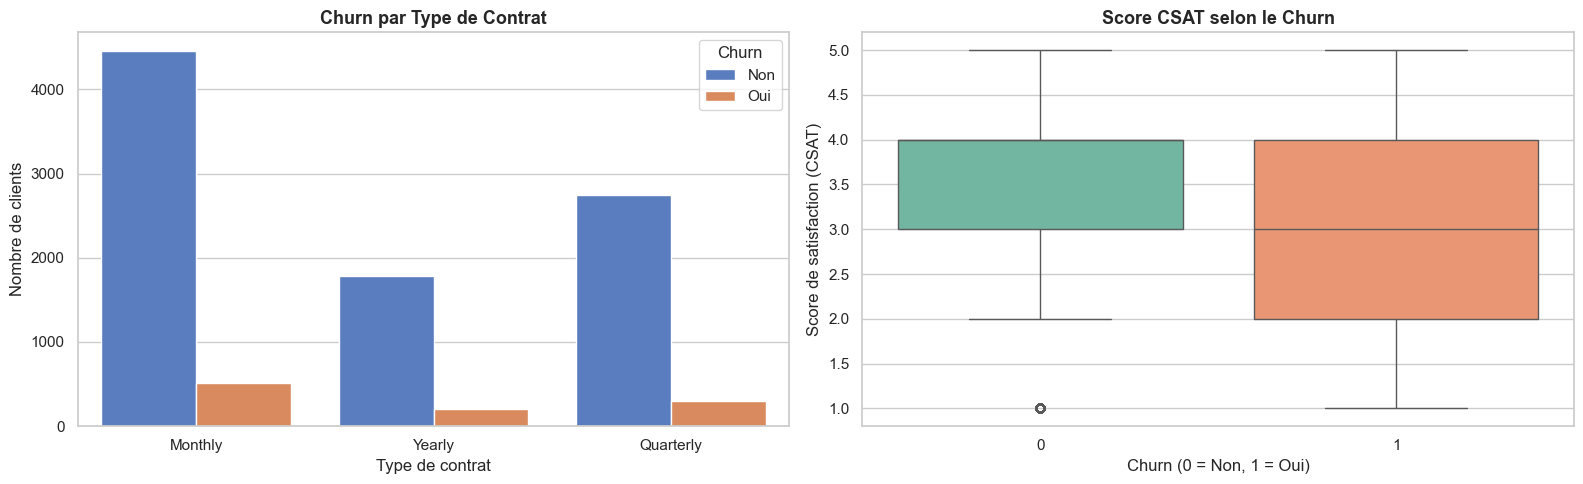

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Churn selon le type de contrat
sns.countplot(x='contract_type', hue='churn', data=df, palette='muted', ax=axes[0])
axes[0].set_title('Churn par Type de Contrat', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Type de contrat')
axes[0].set_ylabel('Nombre de clients')
axes[0].legend(title='Churn', labels=['Non', 'Oui'])

# Churn selon le niveau de satisfaction (CSAT)
sns.boxplot(x='churn', y='csat_score', data=df, palette='Set2', ax=axes[1])
axes[1].set_title('Score CSAT selon le Churn', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Churn (0 = Non, 1 = Oui)')
axes[1].set_ylabel('Score de satisfaction (CSAT)')

plt.tight_layout()
plt.show()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_45396\1678051529.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='churn', y='payment_failures', data=df, palette='coolwarm', ax=axes[0])
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_45396\1678051529.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='churn', y='tenure_months', data=df, palette='Set3', ax=axes[1])


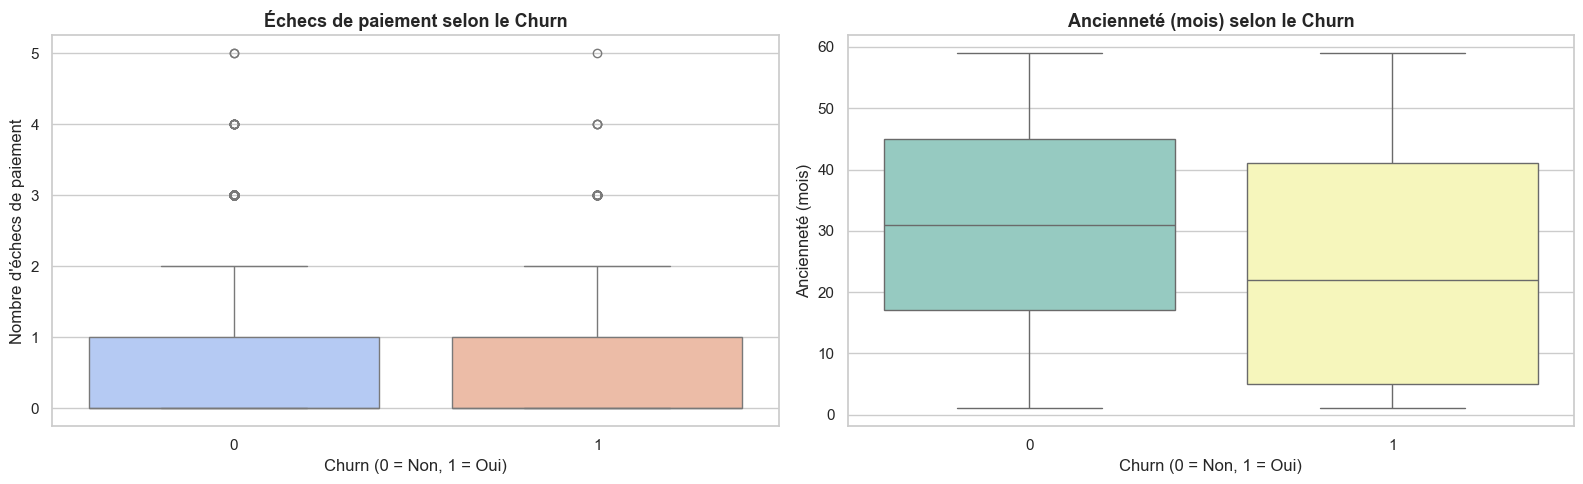

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Churn selon les échecs de paiement
sns.boxplot(x='churn', y='payment_failures', data=df, palette='coolwarm', ax=axes[0])
axes[0].set_title("Échecs de paiement selon le Churn", fontsize=13, fontweight='bold')
axes[0].set_xlabel('Churn (0 = Non, 1 = Oui)')
axes[0].set_ylabel('Nombre d\'échecs de paiement')

# Churn selon l'ancienneté
sns.boxplot(x='churn', y='tenure_months', data=df, palette='Set3', ax=axes[1])
axes[1].set_title("Ancienneté (mois) selon le Churn", fontsize=13, fontweight='bold')
axes[1].set_xlabel('Churn (0 = Non, 1 = Oui)')
axes[1].set_ylabel('Ancienneté (mois)')

plt.tight_layout()
plt.show()

**Interprétation :**
- Les clients avec un abonnement **mensuel** sont plus susceptibles de résilier que ceux avec un abonnement annuel : moins d'engagement contractuel = plus de facilité à partir.
- Les clients qui résilient ont des **scores CSAT plus bas** : un client insatisfait se voit dans les données avant même qu'il parte.
- Les clients qui résilient ont tendance à avoir **plus d'échecs de paiement** — c'est souvent un signal précurseur fort.
- Les clients fidèles ont une **ancienneté plus élevée** : plus on est client depuis longtemps, moins on a tendance à partir.

### 5. Analyse de la matrice de corrélation
Il est important d'identifier les variables redondantes et de comprendre les relations entre features.

Variables numériques (20) : ['age', 'tenure_months', 'monthly_logins', 'weekly_active_days', 'avg_session_time', 'features_used', 'usage_growth_rate', 'last_login_days_ago', 'monthly_fee', 'total_revenue', 'payment_failures', 'support_tickets', 'avg_resolution_time', 'csat_score', 'escalations', 'email_open_rate', 'marketing_click_rate', 'nps_score', 'referral_count', 'churn']


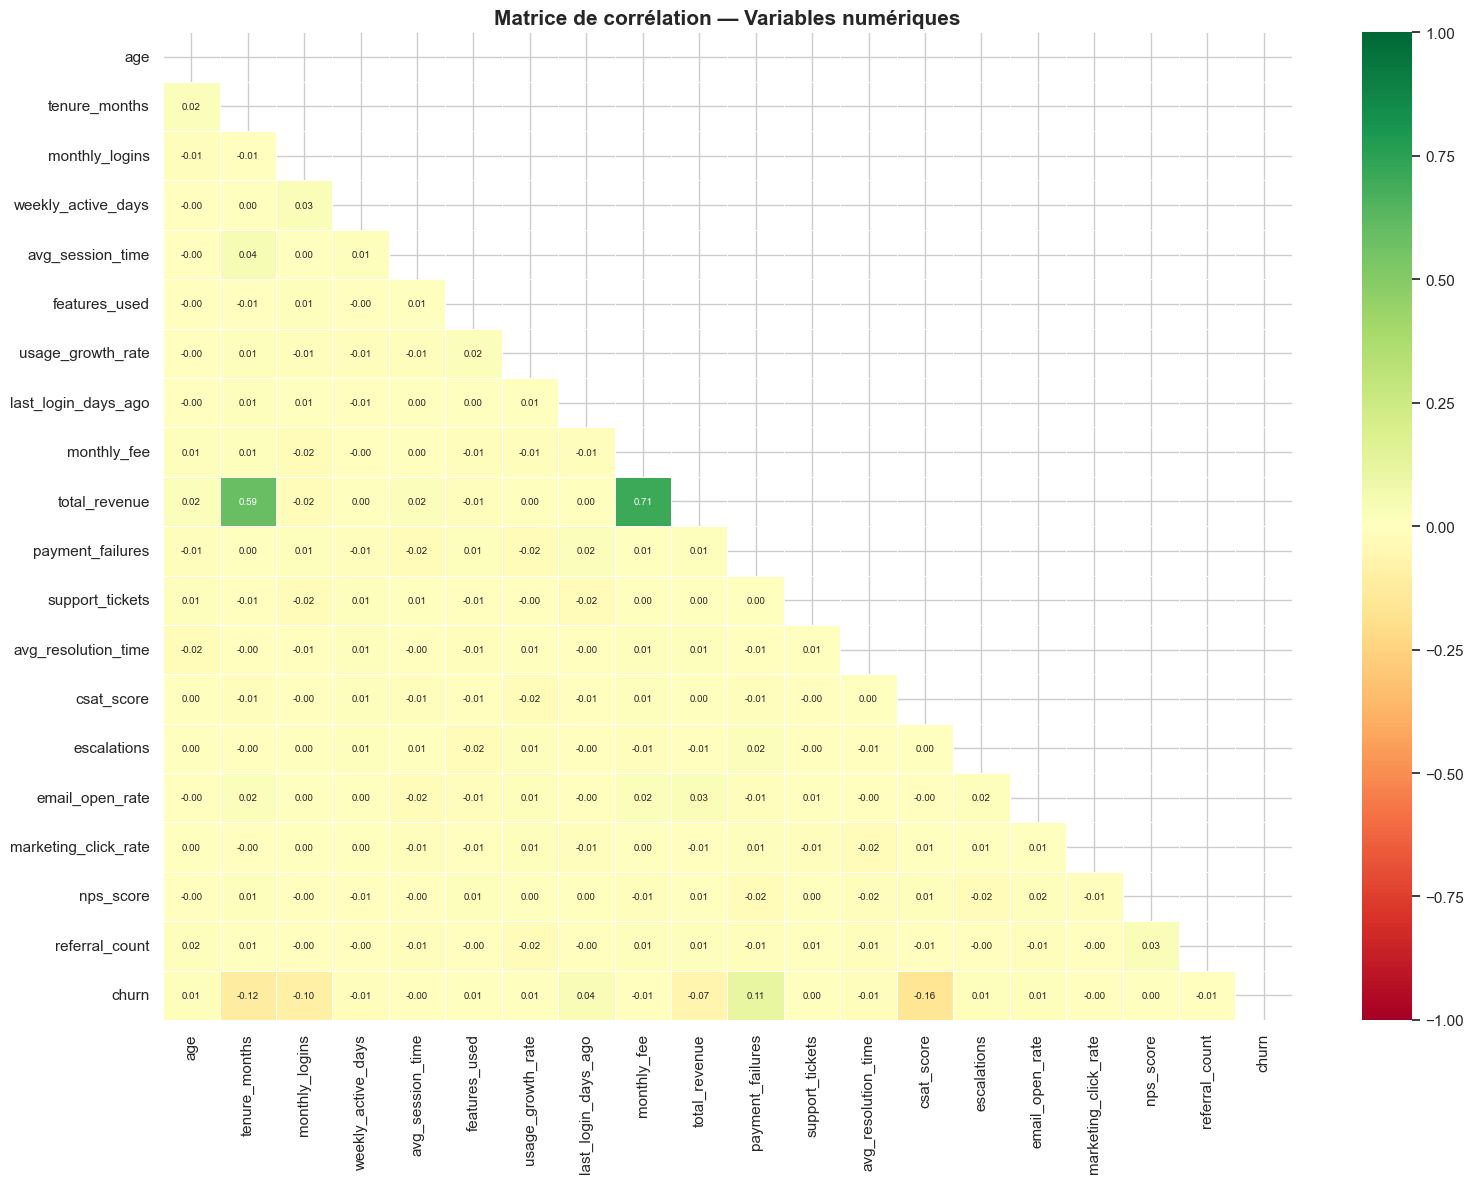

In [9]:
# Sélection des variables numériques uniquement
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Variables numériques ({len(numeric_cols)}) : {numeric_cols}")

corr_matrix = df[numeric_cols].corr()

# Heatmap de corrélation
plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # masque triangle supérieur
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    annot_kws={'size': 7}
)
plt.title('Matrice de corrélation — Variables numériques', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

Top 10 variables les plus corrélées avec le churn :
csat_score            -0.157924
tenure_months         -0.117014
payment_failures       0.112494
monthly_logins        -0.098339
total_revenue         -0.070120
last_login_days_ago    0.037250
email_open_rate        0.011506
age                    0.010155
escalations            0.009561
avg_resolution_time   -0.009172


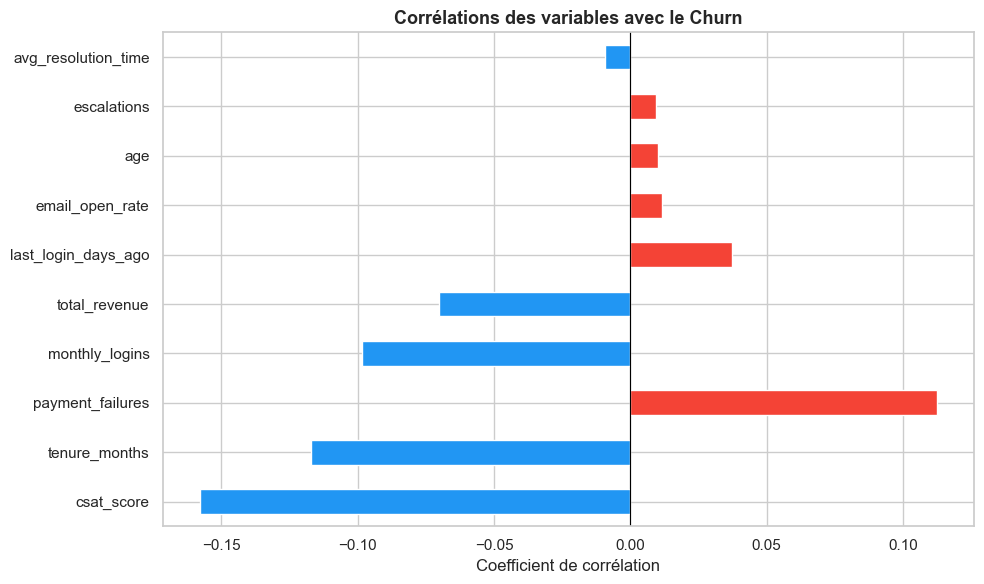

In [10]:
# Top corrélations avec la variable cible 'churn'
churn_corr = corr_matrix['churn'].drop('churn').sort_values(key=abs, ascending=False)
print("Top 10 variables les plus corrélées avec le churn :")
print(churn_corr.head(10).to_string())

# Visualisation
plt.figure(figsize=(10, 6))
colors_bar = ['#F44336' if x > 0 else '#2196F3' for x in churn_corr.head(10).values]
churn_corr.head(10).plot(kind='barh', color=colors_bar)
plt.title('Corrélations des variables avec le Churn', fontsize=13, fontweight='bold')
plt.xlabel('Coefficient de corrélation')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

**Interprétation de la matrice de corrélation :**
- Les variables **positivement corrélées** avec le churn (barres rouges) sont celles dont une valeur élevée augmente le risque de résiliation (ex: échecs de paiement, tickets support).
- Les variables **négativement corrélées** (barres bleues) sont protectrices : une valeur élevée réduit le churn (ex: ancienneté, score CSAT, engagement).
- On vérifie aussi qu'il n'y a pas de variables trop fortement corrélées entre elles (multicolinéarité), ce qui pourrait nuire à l'interprétation de certains modèles.

### 6. Préparation des données (Feature Engineering et Encodage)
Nous allons :
1. Exclure les variables non prédictives comme `customer_id`.
2. Encoder les variables catégorielles.
3. Séparer le jeu de données en features (`X`) et cible (`y`).

In [11]:
from sklearn.model_selection import train_test_split

# Suppression de la colonne ID
df_clean = df.drop(columns=['customer_id'])

# Encodage (One-Hot Encoding pour les catégorielles)
df_encoded = pd.get_dummies(df_clean, drop_first=True)

# Définition des X et y
X = df_encoded.drop(columns=['churn'])
y = df_encoded['churn']

print(f"Dimensions de X après encodage : {X.shape}")
print(f"Nouvelles colonnes créées par One-Hot Encoding :")
categorical_cols = df_clean.select_dtypes(include='object').columns.tolist()
print(f"  Variables catégorielles encodées : {categorical_cols}")
print(f"  Total features : {X.shape[1]}")

# Séparation Train / Test (stratifié)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTaille du jeu d'entraînement : {X_train.shape[0]} lignes")
print(f"Taille du jeu de test : {X_test.shape[0]} lignes")
print(f"\nProportion de churn dans train : {y_train.mean()*100:.2f}%")
print(f"Proportion de churn dans test  : {y_test.mean()*100:.2f}%")
print(" La stratification a bien conservé la proportion de churn dans les deux jeux.")

Dimensions de X après encodage : (10000, 46)
Nouvelles colonnes créées par One-Hot Encoding :
  Variables catégorielles encodées : ['gender', 'country', 'city', 'customer_segment', 'signup_channel', 'contract_type', 'payment_method', 'discount_applied', 'price_increase_last_3m', 'complaint_type', 'survey_response']
  Total features : 46

Taille du jeu d'entraînement : 8000 lignes
Taille du jeu de test : 2000 lignes

Proportion de churn dans train : 10.21%
Proportion de churn dans test  : 10.20%
 La stratification a bien conservé la proportion de churn dans les deux jeux.


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_45396\367401772.py:15: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_clean.select_dtypes(include='object').columns.tolist()


**Conclusion de l'EDA :**

Nous avons :
- Confirmé que le dataset est propre (0 valeur manquante).
- Identifié un **déséquilibre des classes** → nous utiliserons F1-score et ROC AUC.
- Mis en évidence les variables les plus liées au churn : **échecs de paiement, CSAT, type de contrat, ancienneté**.
- Vérifié les corrélations entre variables pour repérer d'éventuelles redondances.
- Préparé un dataset encodé et stratifié prêt pour la modélisation.

Pour prévenir toute fuite de données (data leakage), la **standardisation** sera appliquée après cette séparation, au sein de pipelines lors de l'entraînement des modèles.

Le jeu de données est prêt. Nous pouvons passer à l'étape de modélisation dans le prochain notebook.